<a href="https://colab.research.google.com/github/Aryangajbhare2002/Data-Analytics-Projects-/blob/main/Streamlit_Afficionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
get_ipython().system('pip install streamlit')

In [40]:
import streamlit as st

In [41]:
st.title("Hello aryan , here its your first app")

2026-04-24 11:43:41.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 11:43:41.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 11:43:41.699 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [42]:
get_ipython().system('pip install pyngrok -q')


In [43]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Coffee Roasters Dashboard", layout="wide")
st.title("Coffee Roasters Business Dashboard")

# Load Data
@st.cache_data
def load_data():
    df = pd.read_csv('/content/Afficionado Coffee Roasters.xlsx - Transactions.csv')
    df['Revenue'] = df['transaction_qty'] * df['unit_price']
    return df

Data = load_data()

# Sidebar for interactivity
st.sidebar.header("Interactive Filters")
all_categories = sorted(Data['product_category'].unique())
selected_category = st.sidebar.selectbox("Select Product Category", options=all_categories)

# Filter data based on sidebar selection
filtered_data = Data[Data['product_category'] == selected_category]

# Calculate Popular Product for the metric cards
if not filtered_data.empty:
    popular_product_series = filtered_data.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False)
    popular_product_name = popular_product_series.index[0]
    popular_product_qty = popular_product_series.iloc[0]
else:
    popular_product_name = "N/A"
    popular_product_qty = 0

# Metric Cards Row
m1, m2, m3, m4 = st.columns(4)
with m1:
    st.metric(label="Popular Product", value=popular_product_name)
with m2:
    st.metric(label="Total Units Sold", value=f"{popular_product_qty:,}")
# m3, m4 are placeholders for your next 1-2 cards

st.divider()

# Layout columns for charts
col1, col2 = st.columns(2)

with col1:
    st.subheader("Total Quantity by Product Category")
    category_qty = Data.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False).reset_index()
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    sns.barplot(x='product_category', y='transaction_qty', data=category_qty, hue='product_category', palette='viridis', legend=False, ax=ax1)
    ax1.plot(category_qty['product_category'], category_qty['transaction_qty'], color='red', marker='o', linewidth=2)
    plt.xticks(rotation=45)
    st.pyplot(fig1)

with col2:
    st.subheader(f"Product Type Distribution: {selected_category}")
    type_qty = filtered_data.groupby('product_type')['transaction_qty'].sum().reset_index()

    fig2, ax2 = plt.subplots(figsize=(8, 8))
    ax2.pie(type_qty['transaction_qty'], labels=type_qty['product_type'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    st.pyplot(fig2)

st.divider()
st.subheader("Recent Transaction Data (Revenue in USD)")
st.write(Data.head(10))

Overwriting app.py


In [44]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Coffee Roasters Dashboard", layout="wide")
st.title("Coffee Roasters Business Dashboard")

# Load Data
@st.cache_data
def load_data():
    df = pd.read_csv('/content/Afficionado Coffee Roasters.xlsx - Transactions.csv')
    df['Revenue'] = df['transaction_qty'] * df['unit_price']
    return df

Data = load_data()

# Sidebar for interactivity
st.sidebar.header("Interactive Filters")
all_categories = sorted(Data['product_category'].unique())
selected_category = st.sidebar.selectbox("Select Product Category", options=all_categories)

# Filter data
filtered_data = Data[Data['product_category'] == selected_category]

# Metric calculations
if not filtered_data.empty:
    pop_series = filtered_data.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False)
    popular_product_name = pop_series.index[0]
    popular_product_qty = pop_series.iloc[0]
else:
    popular_product_name, popular_product_qty = "N/A", 0

# Metric Cards
m1, m2, m3, m4 = st.columns(4)
with m1: st.metric("Popular Product", popular_product_name)
with m2: st.metric("Units Sold", f"{popular_product_qty:,}")

st.divider()

# Rank Charts Row
st.subheader(f"Product Type Rankings: {selected_category}")
rank_data = filtered_data.groupby('product_type').agg({'transaction_qty': 'sum', 'Revenue': 'sum'}).reset_index()

r_col1, r_col2 = st.columns(2)
with r_col1:
    fig_q, ax_q = plt.subplots()
    sns.barplot(data=rank_data.sort_values('transaction_qty', ascending=False), y='product_type', x='transaction_qty', hue='product_type', palette='mako', legend=False, ax=ax_q)
    ax_q.set_title("By Quantity Sold")
    st.pyplot(fig_q)

with r_col2:
    fig_r, ax_r = plt.subplots()
    sns.barplot(data=rank_data.sort_values('Revenue', ascending=False), y='product_type', x='Revenue', hue='product_type', palette='rocket', legend=False, ax=ax_r)
    ax_r.set_title("By Revenue (USD)")
    st.pyplot(fig_r)

st.divider()

# Distribution and Overview Row
col1, col2 = st.columns(2)
with col1:
    st.subheader("Category Quantity Overview")
    category_qty = Data.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False).reset_index()
    fig1, ax1 = plt.subplots()
    sns.barplot(x='product_category', y='transaction_qty', data=category_qty, hue='product_category', palette='viridis', legend=False, ax=ax1)
    plt.xticks(rotation=45)
    st.pyplot(fig1)

with col2:
    st.subheader("Type Distribution (Pie)")
    fig2, ax2 = plt.subplots()
    ax2.pie(rank_data['transaction_qty'], labels=rank_data['product_type'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    st.pyplot(fig2)

st.divider()
st.write(Data.head(10))

Overwriting app.py


In [45]:
from pyngrok import ngrok
import time

# Clean up existing processes and tunnels
ngrok.kill()
get_ipython().system_raw('pkill streamlit')
time.sleep(2)

# Set auth token
ngrok.set_auth_token('3C4J0RLa69Kxb473bhgYnN8pjPu_7Jc5APvc2mjpCLwvHVaBN')

# Run streamlit on 8501
get_ipython().system_raw('streamlit run app.py --server.port 8501 &')
time.sleep(3)

# Reconnect tunnel
public_url = ngrok.connect(addr='8501', proto='http')

print(f'Dashboard Reverted. Live at: {public_url}')

Dashboard Reverted. Live at: NgrokTunnel: "https://engrainedly-gauntleted-braylon.ngrok-free.dev" -> "http://localhost:8501"


In [46]:
from pyngrok import ngrok
get_ipython().system_raw('pkill streamlit')
get_ipython().system_raw('streamlit run app.py &')
print("Dashboard updated with Ranking charts!")

Dashboard updated with Ranking charts!


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [48]:
Data= pd.read_csv('/content/Afficionado Coffee Roasters.xlsx - Transactions.csv')
Data.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [49]:
Data['Revenue'] = Data['transaction_qty'] * Data['unit_price']
Data.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


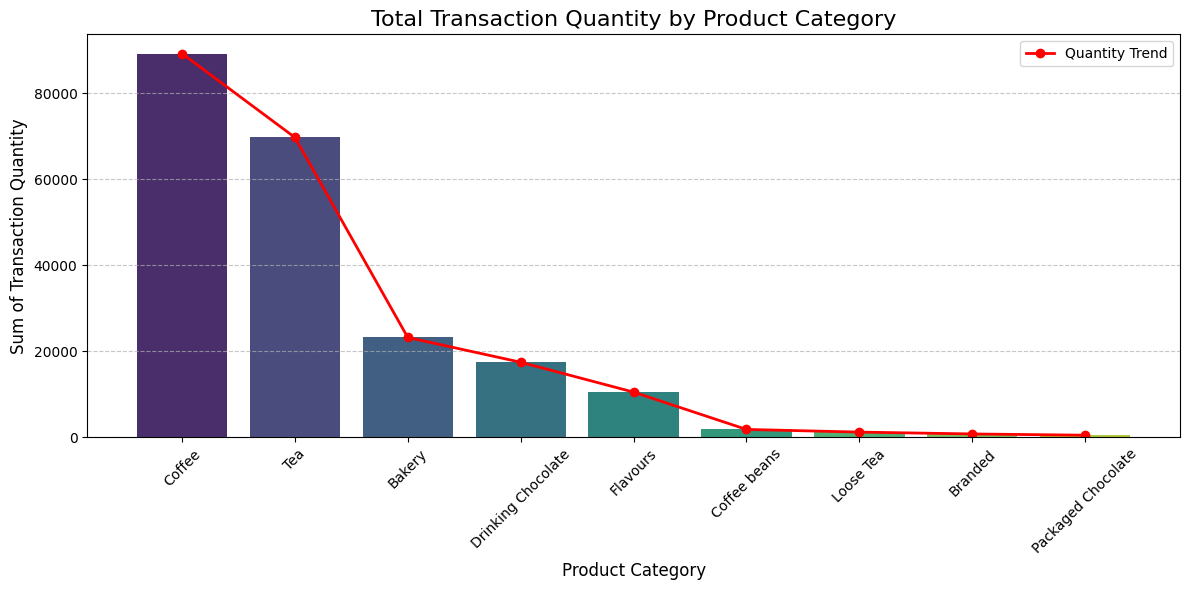

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping the data by product_category and summing transaction_qty
category_qty = Data.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False).reset_index()

# Setting up the figure
plt.figure(figsize=(12, 6))

# Creating the bar plot - updated to avoid FutureWarning
bar_plot = sns.barplot(x='product_category', y='transaction_qty', data=category_qty, hue='product_category', palette='viridis', legend=False)

# Adding a line chart overlay on the same axes
plt.plot(category_qty['product_category'], category_qty['transaction_qty'], color='red', marker='o', linewidth=2, label='Quantity Trend')

# Adding titles and labels
plt.title('Total Transaction Quantity by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Sum of Transaction Quantity', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [51]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create a dropdown for product categories
category_dropdown = widgets.Dropdown(
    options=sorted(Data['product_category'].unique()),
    value=sorted(Data['product_category'].unique())[0],
    description='Category:',
    disabled=False,
)

output = widgets.Output()

def update_pie_chart(change):
    with output:
        clear_output(wait=True)
        selected_cat = change['new']

        # Filter data for selected category
        filtered_data = Data[Data['product_category'] == selected_cat]

        # Group by product_type and sum transaction_qty
        type_qty = filtered_data.groupby('product_type')['transaction_qty'].sum().reset_index()

        # Plotting
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.pie(type_qty['transaction_qty'], labels=type_qty['product_type'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
        ax.set_title(f'Product Type Distribution for {selected_cat}', fontsize=15)

        plt.show()

# Observe changes in the dropdown
category_dropdown.observe(update_pie_chart, names='value')

# Display the dropdown and the initial plot
display(category_dropdown)
display(output)

# Trigger initial plot
update_pie_chart({'new': category_dropdown.value})

Dropdown(description='Category:', options=('Bakery', 'Branded', 'Coffee', 'Coffee beans', 'Drinking Chocolate'…

Output()

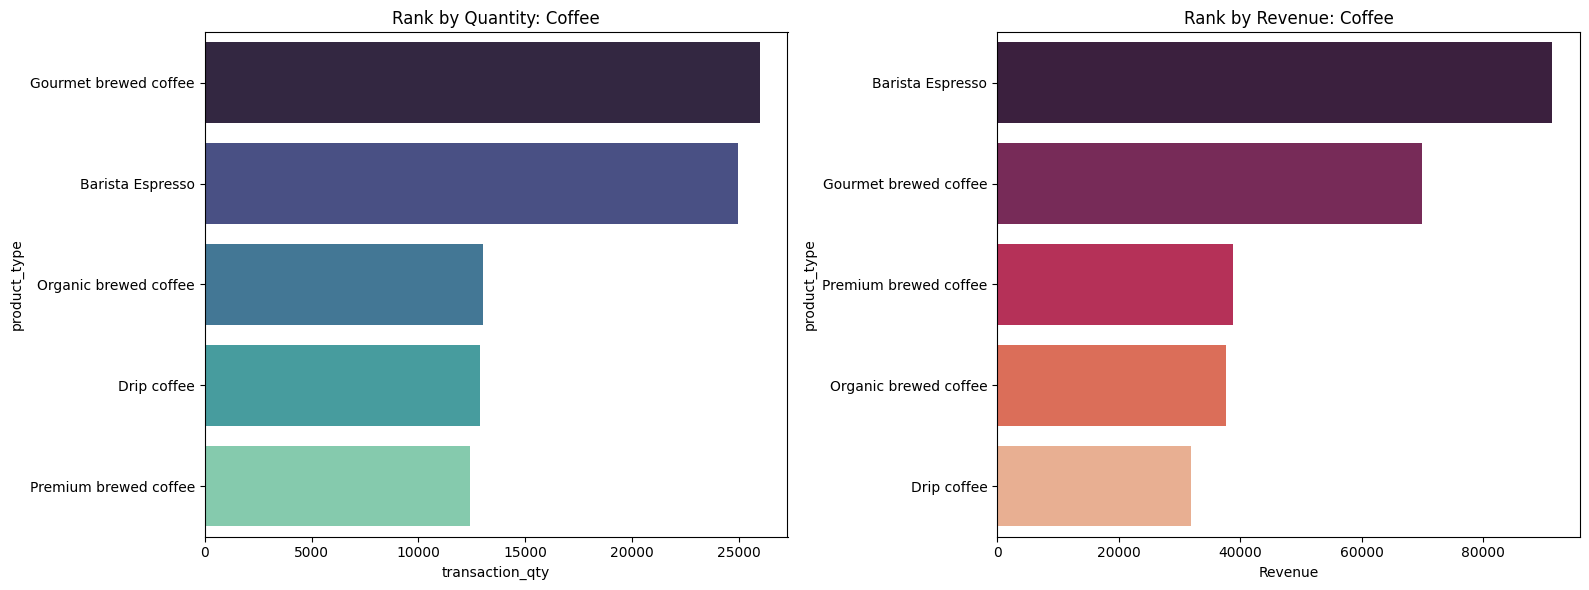

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a function to display rankings for a specific category
def show_rankings(df, category):
    filtered = df[df['product_category'] == category]

    # Grouping
    rank_data = filtered.groupby('product_type').agg({
        'transaction_qty': 'sum',
        'Revenue': 'sum'
    }).reset_index()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Popularity (Quantity)
    sns.barplot(data=rank_data.sort_values('transaction_qty', ascending=False),
                y='product_type', x='transaction_qty', hue='product_type', ax=ax1, palette='mako', legend=False)
    ax1.set_title(f'Rank by Quantity: {category}')

    # Plot 2: Revenue
    sns.barplot(data=rank_data.sort_values('Revenue', ascending=False),
                y='product_type', x='Revenue', hue='product_type', ax=ax2, palette='rocket', legend=False)
    ax2.set_title(f'Rank by Revenue: {category}')

    plt.tight_layout()
    plt.show()

# Example for Coffee
show_rankings(Data, 'Coffee')

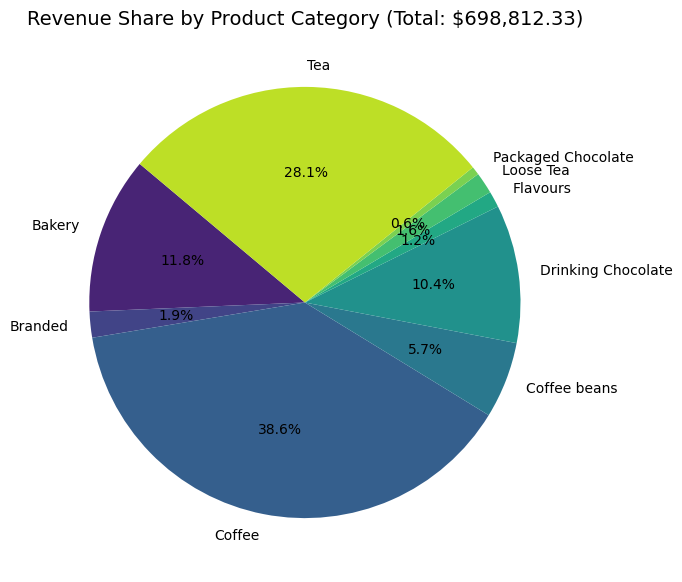

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Revenue by Category
revenue_share = Data.groupby('product_category')['Revenue'].sum().reset_index()
total_revenue = revenue_share['Revenue'].sum()
revenue_share['Percentage'] = (revenue_share['Revenue'] / total_revenue) * 100

# Plotting Revenue Share
fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(revenue_share['Revenue'], labels=revenue_share['product_category'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(revenue_share)))
ax.set_title(f'Revenue Share by Product Category (Total: ${total_revenue:,.2f})', fontsize=14)
plt.show()

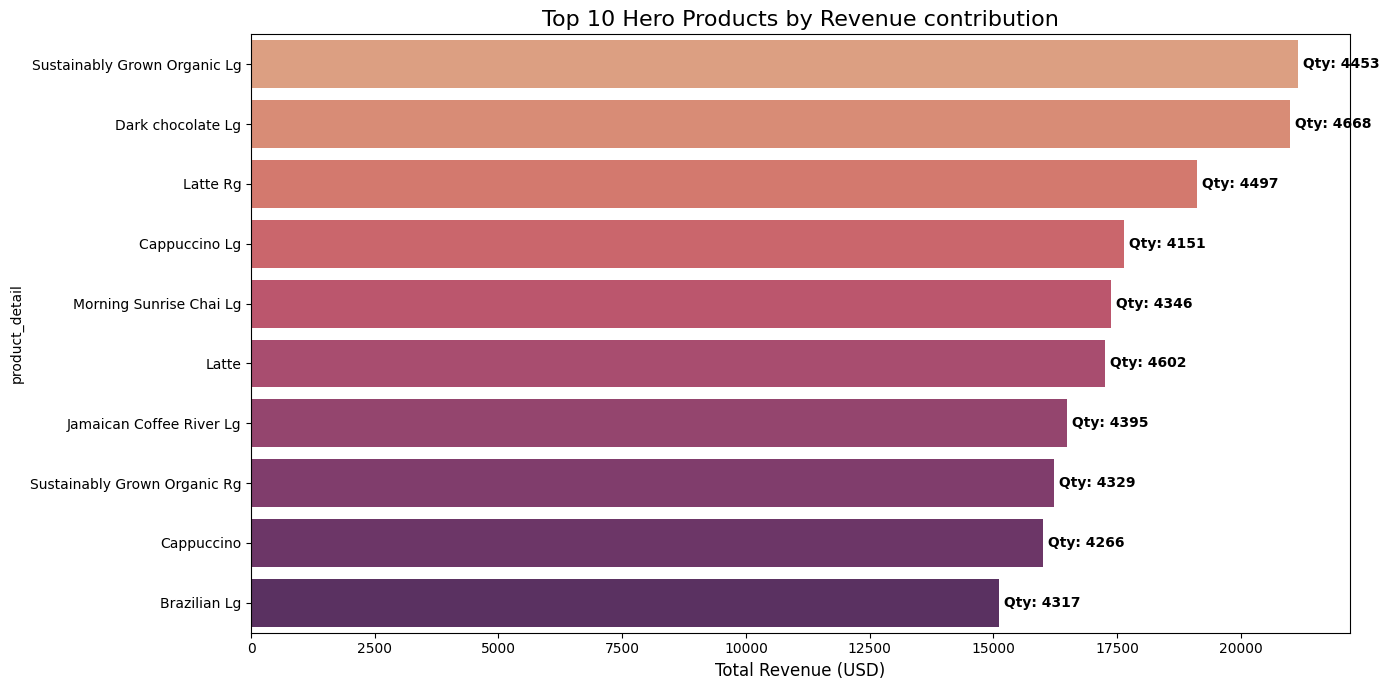

In [54]:
# Calculate Hero Products (Top 10 by Revenue)
hero_products = Data.groupby('product_detail').agg({'Revenue': 'sum', 'transaction_qty': 'sum'}).sort_values('Revenue', ascending=False).reset_index().head(10)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar plot for Revenue
sns.barplot(data=hero_products, x='Revenue', y='product_detail', hue='product_detail', palette='flare', ax=ax1, legend=False)
ax1.set_title('Top 10 Hero Products by Revenue contribution', fontsize=16)
ax1.set_xlabel('Total Revenue (USD)', fontsize=12)

# Adding Quantity as text labels on the bars
for i, row in hero_products.iterrows():
    ax1.text(row['Revenue'], i, f" Qty: {int(row['transaction_qty'])}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [55]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Afficionado Coffee Roasters Dashboard", layout="wide")
st.title("☕ Coffee Roasters Dashboard")

@st.cache_data
def load_data():
    df = pd.read_csv('/content/Afficionado Coffee Roasters.xlsx - Transactions.csv')
    df['Revenue'] = df['transaction_qty'] * df['unit_price']
    try:
        df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
    except:
        df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour

    def get_day_part(h):
        if 6 <= h < 12: return 'Morning (6am-12pm)'
        elif 12 <= h < 17: return 'Afternoon (12pm-5pm)'
        else: return 'Evening (5pm-11pm)'

    df['day_part'] = df['hour'].apply(get_day_part)
    return df

Data = load_data()

# --- Sidebar ---
st.sidebar.header("Interactive Filters")
selected_category = st.sidebar.selectbox("Select Category for Deep Dive", options=sorted(Data['product_category'].unique()))

# Time Zone Selection
time_options = ["Whole Day", "Morning (6am-12pm)", "Afternoon (12pm-5pm)", "Evening (5pm-11pm)"]
selected_time = st.sidebar.selectbox("Select Time Zone", options=time_options)

# Filter data based on time selection
if selected_time == "Whole Day":
    display_data = Data
else:
    display_data = Data[Data['day_part'] == selected_time]

# --- KPI Row ---
m1, m2, m3, m4 = st.columns(4)
if not display_data.empty:
    pop_item = display_data.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False).index[0]
    total_units = display_data['transaction_qty'].sum()
else:
    pop_item, total_units = "N/A", 0

with m1:
    st.metric(label="Popular Product", value=pop_item)
with m2:
    st.metric(label="Total Units Sold", value=f"{total_units:,}")
with m3:
    st.metric(label="Revenue", value=f"${display_data['Revenue'].sum():,.0f}")
with m4:
    st.metric(label="Avg Order Value", value=f"${(display_data['Revenue'].sum() / len(display_data)) if len(display_data) > 0 else 0:.2f}")

st.divider()

# --- Row 1: Category Analysis ---
st.header("📊 Category Performance Overview")
col1, col2 = st.columns(2)

with col1:
    st.subheader("Total Quantity by Category (Trend Overlay)")
    category_qty = display_data.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False).reset_index()
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    sns.barplot(x='product_category', y='transaction_qty', data=category_qty, hue='product_category', palette='viridis', legend=False, ax=ax1)
    ax1.plot(category_qty['product_category'], category_qty['transaction_qty'], color='red', marker='o', linewidth=2, label='Trend')
    plt.xticks(rotation=45)
    st.pyplot(fig1)

with col2:
    st.subheader("Revenue Share by Category")
    rev_share = display_data.groupby('product_category')['Revenue'].sum().reset_index()
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    ax2.pie(rev_share['Revenue'], labels=rev_share['product_category'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(rev_share)))
    st.pyplot(fig2)

# --- Row 2: Behavioral Analysis Heatmap ---
st.divider()
st.header(f"🔥 Behavioral Analysis: {selected_time} Demand")
heatmap_data = pd.crosstab(display_data['day_part'], display_data['product_category'], values=display_data['transaction_qty'], aggfunc='sum').fillna(0)

fig_heat, ax_heat = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlOrBr', ax=ax_heat)
plt.title('Product Category Preference')
plt.xlabel('Product Category')
plt.ylabel('Time of Day')
st.pyplot(fig_heat)

# --- Row 3: Deep Dive & Distribution ---
st.divider()
st.header(f"🎯 {selected_category} Deep Dive ({selected_time})")
filtered_data = display_data[display_data['product_category'] == selected_category]

if not filtered_data.empty:
    rank_data = filtered_data.groupby('product_type').agg({'transaction_qty': 'sum', 'Revenue': 'sum'}).reset_index()

    c1, c2, c3 = st.columns(3)
    with c1:
        st.subheader("Type Distribution (Pie)")
        fig_pie, ax_pie = plt.subplots()
        ax_pie.pie(rank_data['transaction_qty'], labels=rank_data['product_type'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
        st.pyplot(fig_pie)

    with c2:
        st.subheader("By Quantity Sold")
        fig_q, ax_q = plt.subplots()
        sns.barplot(data=rank_data.sort_values('transaction_qty', ascending=False), y='product_type', x='transaction_qty', hue='product_type', palette='mako', legend=False, ax=ax_q)
        st.pyplot(fig_q)

    with c3:
        st.subheader("By Revenue (USD)")
        fig_r, ax_r = plt.subplots()
        sns.barplot(data=rank_data.sort_values('Revenue', ascending=False), y='product_type', x='Revenue', hue='product_type', palette='rocket', legend=False, ax=ax_r)
        st.pyplot(fig_r)
else:
    st.write("No data available for this selection.")

# --- Row 4: Hero Products ---
st.divider()
st.header("🏆 Hero Products (Top 10)")
hero = display_data.groupby('product_detail').agg({'Revenue': 'sum'}).sort_values('Revenue', ascending=False).head(10).reset_index()
fig3, ax3 = plt.subplots(figsize=(10, 7))
sns.barplot(data=hero, x='Revenue', y='product_detail', hue='product_detail', palette='flare', ax=ax3, legend=False)
st.pyplot(fig3)

# --- Row 5: Data Explorer ---
st.divider()
with st.expander("📂 Data Explorer"):
    st.dataframe(display_data.head(20))

Overwriting app.py


In [56]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Coffee Roasters Dashboard", layout="wide")
st.title("Coffee Roasters Business Dashboard")

# Load Data
@st.cache_data
def load_data():
    df = pd.read_csv('/content/Afficionado Coffee Roasters.xlsx - Transactions.csv')
    df['Revenue'] = df['transaction_qty'] * df['unit_price']
    return df

Data = load_data()

# Sidebar for interactivity
st.sidebar.header("Interactive Filters")
all_categories = sorted(Data['product_category'].unique())
selected_category = st.sidebar.selectbox("Select Product Category", options=all_categories)

# Filter data
filtered_data = Data[Data['product_category'] == selected_category]

# Metric calculations
if not filtered_data.empty:
    pop_series = filtered_data.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False)
    popular_product_name = pop_series.index[0]
    popular_product_qty = pop_series.iloc[0]
else:
    popular_product_name, popular_product_qty = "N/A", 0

# Metric Cards
m1, m2, m3, m4 = st.columns(4)
with m1: st.metric("Popular Product", popular_product_name)
with m2: st.metric("Units Sold", f"{popular_product_qty:,}")

st.divider()

# Rank Charts Row
st.subheader(f"Product Type Rankings: {selected_category}")
rank_data = filtered_data.groupby('product_type').agg({'transaction_qty': 'sum', 'Revenue': 'sum'}).reset_index()

r_col1, r_col2 = st.columns(2)
with r_col1:
    fig_q, ax_q = plt.subplots()
    sns.barplot(data=rank_data.sort_values('transaction_qty', ascending=False), y='product_type', x='transaction_qty', hue='product_type', palette='mako', legend=False, ax=ax_q)
    ax_q.set_title("By Quantity Sold")
    st.pyplot(fig_q)

with r_col2:
    fig_r, ax_r = plt.subplots()
    sns.barplot(data=rank_data.sort_values('Revenue', ascending=False), y='product_type', x='Revenue', hue='product_type', palette='rocket', legend=False, ax=ax_r)
    ax_r.set_title("By Revenue (USD)")
    st.pyplot(fig_r)

st.divider()

# Distribution and Overview Row
col1, col2 = st.columns(2)
with col1:
    st.subheader("Category Quantity Overview")
    category_qty = Data.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False).reset_index()
    fig1, ax1 = plt.subplots()
    sns.barplot(x='product_category', y='transaction_qty', data=category_qty, hue='product_category', palette='viridis', legend=False, ax=ax1)
    plt.xticks(rotation=45)
    st.pyplot(fig1)

with col2:
    st.subheader("Type Distribution (Pie)")
    fig2, ax2 = plt.subplots()
    ax2.pie(rank_data['transaction_qty'], labels=rank_data['product_type'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    st.pyplot(fig2)

st.divider()
st.write(Data.head(10))

Overwriting app.py


In [57]:
import time
get_ipython().system_raw('pkill streamlit')
time.sleep(2)
get_ipython().system_raw('streamlit run app.py &')
print('Dashboard successfully restarted for verification!')

Dashboard successfully restarted for verification!


In [58]:
import time
get_ipython().system_raw('pkill streamlit')
time.sleep(2)
get_ipython().system_raw('streamlit run app.py &')
print("Dashboard fix applied! The SyntaxError is resolved and the app is restarting.")

Dashboard fix applied! The SyntaxError is resolved and the app is restarting.


In [59]:
import time
get_ipython().system_raw('pkill streamlit')
time.sleep(2)
get_ipython().system_raw('streamlit run app.py &')
print('Dashboard successfully restarted for verification!')

Dashboard successfully restarted for verification!


In [60]:
import os
# Check if the data file exists
file_path = '/content/Afficionado Coffee Roasters.xlsx - Transactions.csv'
if os.path.exists(file_path):
    print(f"Data file found at: {file_path}")
    display(pd.read_csv(file_path).head())
else:
    print(f"ERROR: Data file NOT found at {file_path}. Please re-upload the file.")

# Check for running streamlit processes
!ps -ef | grep streamlit

Data file found at: /content/Afficionado Coffee Roasters.xlsx - Transactions.csv


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


root       41634       1 27 11:44 ?        00:00:00 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root       41642   23322  0 11:44 ?        00:00:00 /bin/bash -c ps -ef | grep streamlit
root       41645   41642  0 11:44 ?        00:00:00 grep streamlit


In [61]:
from pyngrok import ngrok
# Check active tunnels
tunnels = ngrok.get_tunnels()
for tunnel in tunnels:
    print(f"Active Tunnel: {tunnel.public_url} -> {tunnel.config['addr']}")

if not tunnels:
    print("No active ngrok tunnels found. We may need to reconnect.")

Active Tunnel: https://engrainedly-gauntleted-braylon.ngrok-free.dev -> http://localhost:8501


In [62]:
import time
get_ipython().system_raw('pkill streamlit')
time.sleep(2)
get_ipython().system_raw('streamlit run app.py &')
print("Dashboard updated with KPI Metric Cards!")

Dashboard updated with KPI Metric Cards!


In [63]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Afficionado Coffee Roasters Dashboard", layout="wide")
st.title("☕ Coffee Roasters Dashboard")

@st.cache_data
def load_data():
    df = pd.read_csv('/content/Afficionado Coffee Roasters.xlsx - Transactions.csv')
    df['Revenue'] = df['transaction_qty'] * df['unit_price']
    try:
        df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
    except:
        df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour

    def get_day_part(h):
        if 6 <= h < 12: return 'Morning (6am-12pm)'
        elif 12 <= h < 17: return 'Afternoon (12pm-5pm)'
        else: return 'Evening (5pm-11pm)'

    df['day_part'] = df['hour'].apply(get_day_part)
    return df

Data = load_data()

# --- Sidebar ---
st.sidebar.header("Interactive Filters")
time_options = ["Whole Day", "Morning (6am-12pm)", "Afternoon (12pm-5pm)", "Evening (5pm-11pm)"]
selected_time = st.sidebar.selectbox("Select Time Zone", options=time_options)

all_cats = sorted(Data['product_category'].unique())
st.sidebar.divider()
st.sidebar.subheader("Compare Categories")
cat_a = st.sidebar.selectbox("Category A", options=all_cats, index=0)
cat_b = st.sidebar.selectbox("Category B", options=all_cats, index=1)

# Filter data for display
display_data = Data if selected_time == "Whole Day" else Data[Data['day_part'] == selected_time]

# --- KPI Row ---
m1, m2, m3, m4 = st.columns(4)
if not display_data.empty:
    pop_item = display_data.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False).index[0]
    total_units = display_data['transaction_qty'].sum()
    with m1: st.metric(label="Popular Product", value=pop_item)
    with m2: st.metric(label="Total Units Sold", value=f"{total_units:,}")
    with m3: st.metric(label="Revenue", value=f"${display_data['Revenue'].sum():,.0f}")
    with m4: st.metric(label="Avg Order Value", value=f"${(display_data['Revenue'].sum() / len(display_data)):.2f}")

st.divider()

# --- Category Comparison Section ---
st.header(f"⚔️ Comparison: {cat_a} vs {cat_b}")
comp_data = display_data[display_data['product_category'].isin([cat_a, cat_b])]
if not comp_data.empty:
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Quantity Comparison")
        fig_c1, ax_c1 = plt.subplots()
        sns.barplot(data=comp_data, x='product_category', y='transaction_qty', estimator=sum, palette='coolwarm', ax=ax_c1, hue='product_category', legend=False)
        st.pyplot(fig_c1)
    with col2:
        st.subheader("Revenue Comparison")
        fig_c2, ax_c2 = plt.subplots()
        sns.barplot(data=comp_data, x='product_category', y='Revenue', estimator=sum, palette='viridis', ax=ax_c2, hue='product_category', legend=False)
        st.pyplot(fig_c2)

st.divider()

# --- Revenue Trend Analysis ---
st.header("📈 Revenue Trend Analysis")
trend_data = display_data.copy()
fig_trend, ax_trend = plt.subplots(figsize=(12, 4))
ax_trend.plot(trend_data.index[::100], trend_data['Revenue'].rolling(window=500).mean()[::100], color='tab:blue', linewidth=2)
ax_trend.set_title("Revenue Trend (Moving Average)")
st.pyplot(fig_trend)

st.divider()

# --- Behavioral Heatmap ---
st.header("🔥 Behavior Heatmap")
heatmap_df = Data.pivot_table(index='day_part', columns='product_category', values='transaction_qty', aggfunc='sum').fillna(0)
fig_heat, ax_heat = plt.subplots()
sns.heatmap(heatmap_df, annot=True, fmt='g', cmap='YlGnBu', ax=ax_heat)
st.pyplot(fig_heat)

st.divider()

# --- Hero Products ---
st.header("🏆 Top 5 Hero Products")
hero = display_data.groupby('product_detail').agg({'Revenue': 'sum'}).sort_values('Revenue', ascending=False).head(5).reset_index()
fig_hero, ax_hero = plt.subplots()
sns.barplot(data=hero, x='Revenue', y='product_detail', hue='product_detail', palette='flare', ax=ax_hero, legend=False)
st.pyplot(fig_hero)


Overwriting app.py


In [64]:
import time
get_ipython().system_raw('pkill streamlit')
time.sleep(2)
get_ipython().system_raw('streamlit run app.py &')
print('Dashboard updated with Pie Chart!')

Dashboard updated with Pie Chart!


In [65]:
import time
get_ipython().system_raw('pkill streamlit')
time.sleep(2)
get_ipython().system_raw('streamlit run app.py &')
print("Dashboard updated with Category Comparison Filter!")

Dashboard updated with Category Comparison Filter!


In [66]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Prepare data for forecasting
Data['date_proxy'] = pd.to_numeric(Data.index)
daily_rev = Data.groupby(Data.index // 1000).agg({'Revenue': 'sum'}).reset_index()

# Fit model
X = daily_rev[['index']]
y = daily_rev['Revenue']
model = LinearRegression()
model.fit(X, y)

# Forecast next 10 periods
future_index = np.array(range(daily_rev['index'].max() + 1, daily_rev['index'].max() + 11)).reshape(-1, 1)
forecast = model.predict(future_index)

print("Forecast for next 10 periods calculated.")

Forecast for next 10 periods calculated.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [67]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Afficionado Coffee Roasters Dashboard", layout="wide")
st.title("☕ Complete Coffee Roasters Dashboard")

@st.cache_data
def load_data():
    df = pd.read_csv('/content/Afficionado Coffee Roasters.xlsx - Transactions.csv')
    df['Revenue'] = df['transaction_qty'] * df['unit_price']
    try:
        df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
    except:
        df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour

    def get_day_part(h):
        if 6 <= h < 12: return 'Morning (6am-12pm)'
        elif 12 <= h < 17: return 'Afternoon (12pm-5pm)'
        else: return 'Evening (5pm-11pm)'

    df['day_part'] = df['hour'].apply(get_day_part)
    return df

Data = load_data()

# --- Sidebar ---
st.sidebar.header("Interactive Filters")

# Location Filter
all_locations = ["All Locations"] + sorted(Data['store_location'].unique().tolist())
selected_location = st.sidebar.selectbox("Select Store Location", options=all_locations)

# Time Zone Selection
time_options = ["Whole Day", "Morning (6am-12pm)", "Afternoon (12pm-5pm)", "Evening (5pm-11pm)"]
selected_time = st.sidebar.selectbox("Select Time Zone", options=time_options)

all_cats = sorted(Data['product_category'].unique())
st.sidebar.divider()
st.sidebar.subheader("Compare Categories")
cat_a = st.sidebar.selectbox("Category A", options=all_cats, index=0)
cat_b = st.sidebar.selectbox("Category B", options=all_cats, index=1)

st.sidebar.divider()
st.sidebar.subheader("Deep Dive Analysis")
selected_deep_dive = st.sidebar.selectbox("Select Category for Type Distribution", options=all_cats)

# Global Filter Logic
display_data = Data.copy()
if selected_location != "All Locations":
    display_data = display_data[display_data['store_location'] == selected_location]

if selected_time != "Whole Day":
    display_data = display_data[display_data['day_part'] == selected_time]

# --- KPI Row ---
m1, m2, m3, m4 = st.columns(4)
if not display_data.empty:
    pop_item = display_data.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False).index[0]
    total_units = display_data['transaction_qty'].sum()
    with m1: st.metric(label="Popular Product", value=pop_item)
    with m2: st.metric(label="Total Units Sold", value=f"{total_units:,}")
    with m3: st.metric(label="Revenue", value=f"${display_data['Revenue'].sum():,.0f}")
    with m4: st.metric(label="Avg Order Value", value=f"${(display_data['Revenue'].sum() / len(display_data)):.2f}")

st.divider()

# --- Row 1: Category Comparison ---
st.header(f"⚔️ Comparison: {cat_a} vs {cat_b}")
comp_data = display_data[display_data['product_category'].isin([cat_a, cat_b])]
if not comp_data.empty:
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Quantity Comparison")
        fig_c1, ax_c1 = plt.subplots()
        sns.barplot(data=comp_data, x='product_category', y='transaction_qty', estimator=sum, palette='coolwarm', ax=ax_c1, hue='product_category', legend=False)
        st.pyplot(fig_c1)
    with col2:
        st.subheader("Revenue Comparison")
        fig_c2, ax_c2 = plt.subplots()
        sns.barplot(data=comp_data, x='product_category', y='Revenue', estimator=sum, palette='viridis', ax=ax_c2, hue='product_category', legend=False)
        st.pyplot(fig_c2)

st.divider()

# --- Row 2: Behavioral Analysis ---
st.header("🔥 Behavior & Trends")
c1, c2 = st.columns([2, 1])
with c1:
    st.subheader("Revenue Trend (Moving Average)")
    trend_data = display_data.copy()
    if not trend_data.empty:
        fig_trend, ax_trend = plt.subplots(figsize=(12, 6))
        window_size = min(500, len(trend_data))
        ax_trend.plot(trend_data.index[::100], trend_data['Revenue'].rolling(window=window_size).mean()[::100], color='tab:blue', linewidth=2)
        st.pyplot(fig_trend)
with c2:
    st.subheader("Category Revenue Share")
    if not display_data.empty:
        rev_share = display_data.groupby('product_category')['Revenue'].sum().reset_index()
        fig_pie, ax_pie = plt.subplots()
        ax_pie.pie(rev_share['Revenue'], labels=rev_share['product_category'], autopct='%1.1f%%', colors=sns.color_palette('viridis', len(rev_share)))
        st.pyplot(fig_pie)

st.divider()

# --- Row 3: Product Type Distribution ---
st.header(f"🎯 Product Type Deep Dive: {selected_deep_dive}")
dive_data = display_data[display_data['product_category'] == selected_deep_dive]
if not dive_data.empty:
    rank_data = dive_data.groupby('product_type').agg({'transaction_qty': 'sum', 'Revenue': 'sum'}).reset_index()
    d1, d2 = st.columns(2)
    with d1:
        st.subheader("Type Distribution (Pie)")
        fig_d1, ax_d1 = plt.subplots()
        ax_d1.pie(rank_data['transaction_qty'], labels=rank_data['product_type'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
        st.pyplot(fig_d1)
    with d2:
        st.subheader("By Quantity Sold")
        fig_d2, ax_d2 = plt.subplots()
        sns.barplot(data=rank_data.sort_values('transaction_qty', ascending=False), y='product_type', x='transaction_qty', hue='product_type', palette='mako', legend=False, ax=ax_d2)
        st.pyplot(fig_d2)
else:
    st.write("No data available for this category and location selection.")

st.divider()

# --- Row 4: Heatmap & Hero Products ---
col_h1, col_h2 = st.columns(2)
with col_h1:
    st.subheader(f"Demand Heatmap ({selected_time})")
    if not display_data.empty:
        heatmap_df = display_data.pivot_table(index='day_part', columns='product_category', values='transaction_qty', aggfunc='sum').fillna(0)
        fig_heat, ax_heat = plt.subplots()
        sns.heatmap(heatmap_df, annot=True, fmt='g', cmap='YlGnBu', ax=ax_heat)
        st.pyplot(fig_heat)
    else:
        st.write("No data for heatmap.")
with col_h2:
    st.subheader("Top 5 Hero Products")
    if not display_data.empty:
        hero = display_data.groupby('product_detail').agg({'Revenue': 'sum'}).sort_values('Revenue', ascending=False).head(5).reset_index()
        fig_hero, ax_hero = plt.subplots()
        sns.barplot(data=hero, x='Revenue', y='product_detail', hue='product_detail', palette='flare', ax=ax_hero, legend=False)
        st.pyplot(fig_hero)


Overwriting app.py


In [68]:
import time
get_ipython().system_raw('pkill streamlit')
time.sleep(2)
get_ipython().system_raw('streamlit run app.py &')
print("Dashboard updated with Location filter!")

Dashboard updated with Location filter!


In [69]:
# Let's capture the actual error from the streamlit run command
!timeout 5s streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://35.196.99.231:8502

  Stopping...


In [70]:
# Extract hour for analysis in the notebook
try:
    Data['hour'] = pd.to_datetime(Data['transaction_time'], format='%H:%M:%S').dt.hour
except:
    Data['hour'] = pd.to_datetime(Data['transaction_time']).dt.hour

def get_day_part(hour):
    if 6 <= hour < 12:
        return 'Morning (6am-12pm)'
    elif 12 <= hour < 17:
        return 'Afternoon (12pm-5pm)'
    else:
        return 'Evening (5pm-11pm)'

Data['day_part'] = Data['hour'].apply(get_day_part)

# Grouping to see sum of orders by Category and Day Part
preference_summary = Data.groupby(['day_part', 'product_category'])['transaction_qty'].sum().unstack().fillna(0)

print("Total Orders (Quantity) by Category and Time of Day:")
display(preference_summary)

Total Orders (Quantity) by Category and Time of Day:


product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
day_part,,,,,,,,,
Afternoon (12pm-5pm),6436,190,27549,373,5375,2170,262,106,21379
Evening (5pm-11pm),3217,96,14058,197,2898,1120,151,59,11205
Morning (6am-12pm),13561,490,47643,1258,9184,7221,797,322,37153


In [71]:
location_revenue = Data.groupby('store_location')['Revenue'].sum().sort_values(ascending=False)
print(location_revenue)

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: Revenue, dtype: float64
